## Implementing a deep convolutional neural network using PyTorch

### The multilayer CNN architecture

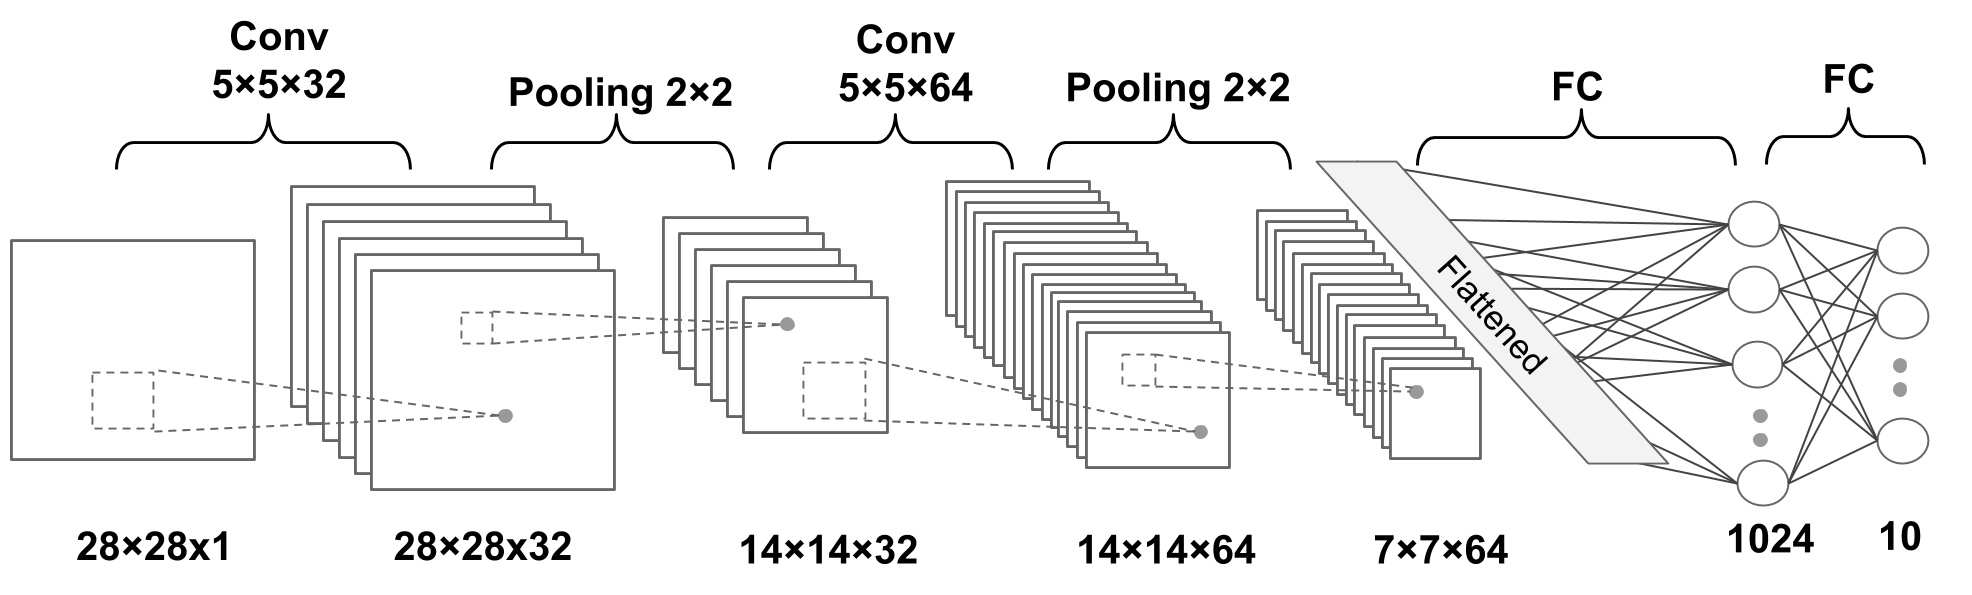

In [1]:
from IPython.display import Image
Image(filename='14_12.png', width=800)

### Loading and preprocessing the data

In [2]:
import ssl
import certifi
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import Subset

# Use certifi CA bundle to avoid macOS SSL certificate issues when downloading MNIST.
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

image_path = './'
transform = transforms.Compose([transforms.ToTensor()])

mnist_dataset = torchvision.datasets.MNIST(
    root=image_path,
    train=True,
    transform=transform,
    download=True,
 )

mnist_valid_dataset = Subset(mnist_dataset, torch.arange(10000))
mnist_train_dataset = Subset(mnist_dataset, torch.arange(10000, len(mnist_dataset)))
mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path,
    train=False,
    transform=transform,
    download=True,
 )
print(f"Training dataset size: {len(mnist_train_dataset)}")
print(f"Validation dataset size: {len(mnist_valid_dataset)}")
print(f"Testing dataset size: {len(mnist_test_dataset)}")

Training dataset size: 50000
Validation dataset size: 10000
Testing dataset size: 10000


In [3]:
from torch.utils.data import DataLoader


batch_size = 64
torch.manual_seed(1)
train_dl = DataLoader(mnist_train_dataset, batch_size, shuffle=True)
valid_dl = DataLoader(mnist_valid_dataset, batch_size, shuffle=False)

### Implementing a CNN using the torch.nn module

#### Configuring CNN layers in PyTorch

 * **Conv2d:** `torch.nn.Conv2d`
   * `out_channels`
   * `kernel_size`
   * `stride`
   * `padding`
   
   
 * **MaxPool2d:** `torch.nn.MaxPool2d`
   * `kernel_size`
   * `stride`
   * `padding`
   
   
 * **Dropout** `torch.nn.Dropout`
   * `p`

### Constructing a CNN in PyTorch
## Note:
#### * Conv2D class assumes that inputs are in NCHW format by default
##### where, N stands for the number of images within the batch, C stands for channels, and H and W stand for height and width

##### * TensorFlow, use NHWC format

In [4]:
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=2))
model.add_module('relu1', nn.ReLU())        
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))  # if the stride parameter is not specified in MaxPool2D, by default, it is set equal to the pooling kernel size
model.add_module('conv2', nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2))
model.add_module('relu2', nn.ReLU())        
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))      

x = torch.ones((4, 1, 28, 28)) # Conv2D class assumes that inputs are in NCHW format, where N is the batch size, C is the number of channels, H is the height, and W is the width.
print(model(x).shape)


torch.Size([4, 64, 7, 7])


#### we want to add is a fully connected layer for implementing a classifier on top of our convolutional and pooling layers. 
#### The input to this layer must have rank 2, that is, shape [batch- size × input_units]. Thus, we need to flatten the output of the previous layers to meet this requirement for the fully connected layer

In [5]:
model.add_module('flatten', nn.Flatten()) 

x = torch.ones((4, 1, 28, 28))
print(model(x).shape)

torch.Size([4, 3136])


In [6]:
model.add_module('fc1', nn.Linear(3136, 1024)) 
model.add_module('relu3', nn.ReLU()) 
"""
The argument p that denotes the drop probability p_drop, which is used to determine the probability of dropping the input units during training. 
When calling this layer, its behavior can be controlled via model.train() and model.eval(), to specify whether this call will be made during training or during the inference.
"""
model.add_module('dropout', nn.Dropout(p=0.5)) 

model.add_module('fc2', nn.Linear(1024, 10)) 
"""
The softmax function is already used internally inside PyTorch's CrossEntropyLoss implementation, 
which is why don't have to explicitly add it as a layer after the output layer.
"""

"\nThe softmax function is already used internally inside PyTorch's CrossEntropyLoss implementation, \nwhich is why don't have to explicitly add it as a layer after the output layer.\n"

In [7]:
# device = torch.device("cuda:0")
device = torch.device("cpu")

model = model.to(device) 

## Loss function and Optimizer


In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # gradient-based optimization method, The key advantage of Adam is in the choice of update step size derived from the running average of gradient moments

# Training

In [9]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device) 
            y_batch = y_batch.to(device) 
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()*y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)
        
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device) 
                y_batch = y_batch.to(device) 
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item()*y_batch.size(0) 
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float() 
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)
        
        print(f'Epoch {epoch+1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f}')
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [10]:
# # Training the model
torch.manual_seed(1)
num_epochs = 5
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.9483 val_accuracy: 0.9807
Epoch 2 accuracy: 0.9836 val_accuracy: 0.9838
Epoch 3 accuracy: 0.9884 val_accuracy: 0.9887
Epoch 4 accuracy: 0.9915 val_accuracy: 0.9885
Epoch 5 accuracy: 0.9929 val_accuracy: 0.9884


## Saving the model and/or reloding the model

In [11]:
## Method 1: Saving the entire model (architecture + learned parameters)
# path = 'MNIST_classifier.pt' 
# torch.save(model, path) # torch.save() will save both the model architecture and all the learned parameters

# ## Method 2: Save only the learned parameters (state_dict) of the model
# path_weightsonly = 'MNIST_classifier_weightsOnly.pt' 
# torch.save(model.state_dict(), path_weightsonly)


# # Reload the model
# model = torch.load(path, weights_only=False) # Method 1
# model.load_state_dict(torch.load(path_weightsonly)) # Method 2


## Visualize the learning curves

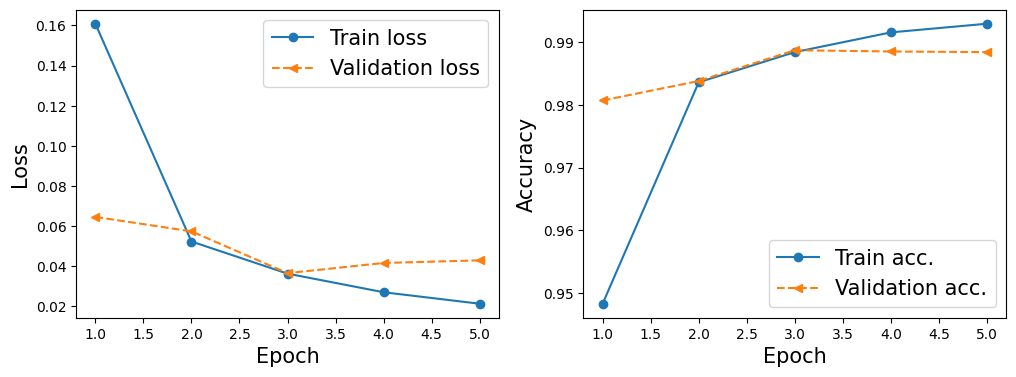

In [12]:
import matplotlib.pyplot as plt
import numpy as np


x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '-o', label='Train loss')
ax.plot(x_arr, hist[1], '--<', label='Validation loss')
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '-o', label='Train acc.')
ax.plot(x_arr, hist[3], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)

#plt.savefig('figures/14_13.png')
plt.show()

### Evaluate the trained model on the test dataset

In [13]:
# torch.cuda.synchronize()
# model_cpu = model.cpu()
pred = model(mnist_test_dataset.data.unsqueeze(1) / 255.)
is_correct = (torch.argmax(pred, dim=1) == mnist_test_dataset.targets).float()
print(f'Test accuracy: {is_correct.mean():.4f}') 


Test accuracy: 0.9916


### Plot
#### we can get the prediction results in the form of class-membership probabilities and convert them to predicted labels by using the torch.argmax function to find the element with the maximum probability. 
#### We will do this for a batch of 12 examples and visualize the input and predicted labels

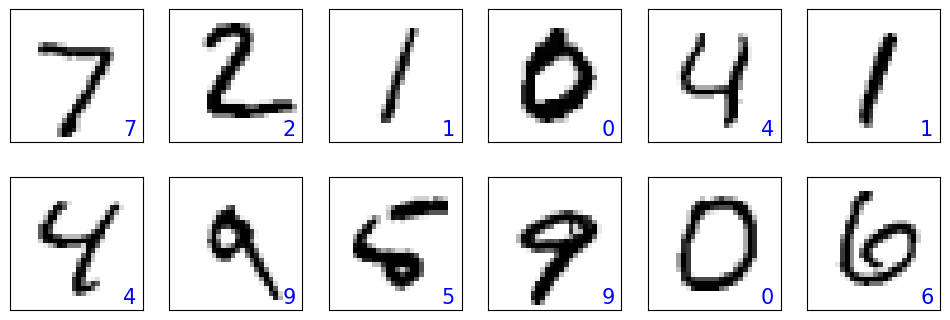

In [14]:
fig = plt.figure(figsize=(12, 4))
for i in range(12):
    ax = fig.add_subplot(2, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    img = mnist_test_dataset[i][0][0, :, :]
    pred = model(img.unsqueeze(0).unsqueeze(1)) # alternatively: mnist_test_dataset.data[i].float()
    y_pred = torch.argmax(pred)
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1, y_pred.item(), 
            size=15, color='blue',
            horizontalalignment='center',
            verticalalignment='center', 
            transform=ax.transAxes)
    
#plt.savefig('figures/14_14.png')
plt.show()